# 03c. Algorithm Comparison Across All Configurations

**Project:** KPI-RAG: Explainable Root-Cause Analysis for 5G Networks
**Stage:** Phase 1 — Algorithm Ablation

## Purpose

Notebook 03 revealed that Config A (64-dim) outperformed Config C (582-dim) using Random Forest.
Two possible explanations:

1. **Feature-side:** Additional dimensions confuse the model (curse of dimensionality)
2. **Algorithm-side:** Random Forest cannot exploit the extra features effectively

This notebook tests hypothesis 2 by running four algorithms on all three feature configurations,
producing a 4 x 3 x 2 = 24 model comparison.

## Algorithms Tested

| Algorithm | Type | Expected Strength |
|---|---|---|
| Random Forest | Bagging | Robust baseline, low tuning |
| XGBoost | Boosting | Best in class on small structured data |
| LightGBM | Boosting | Fast, handles high-cardinality |
| CatBoost | Boosting | Handles categorical features natively |

## Feature Configurations

| Config | Dims | Content |
|---|---|---|
| A | 64 | Statistics only |
| B | 320 | Statistics + Patchwise Scale |
| C | 582 | Full vector |

## Output

Complete 4 x 3 result table for both binary detection and fault classification tasks.

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import os
import json
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

warnings.filterwarnings('ignore')

COLORS = {
    'normal':     '#2E6DB4',
    'anomaly':    '#C0392B',
    'jamming':    '#E67E22',
    'synthetic':  '#85929E',
    'axis':       '#2C3E50',
    'grid':       '#F2F4F6',
    'background': '#FFFFFF',
}

DATA_DIR = r'C:\Users\DELL\Desktop\kpi_rag\data'

print('Loading feature matrices and labels...')

X_full       = np.load(os.path.join(DATA_DIR, 'X_features.npy'))
y_binary     = np.load(os.path.join(DATA_DIR, 'y_binary.npy'))
y_multiclass = np.load(os.path.join(DATA_DIR, 'y_multiclass.npy'))
train_idx    = np.load(os.path.join(DATA_DIR, 'train_idx.npy'))
test_idx     = np.load(os.path.join(DATA_DIR, 'test_idx.npy'))

with open(os.path.join(DATA_DIR, 'type_to_int.json')) as f:
    type_to_int = json.load(f)

X_A = X_full[:, :64]
X_B = X_full[:, :320]
X_C = X_full[:, :582]

y_bin_train, y_bin_test = y_binary[train_idx], y_binary[test_idx]
y_mc_train,  y_mc_test  = y_multiclass[train_idx], y_multiclass[test_idx]

print(f'Config A: {X_A.shape}')
print(f'Config B: {X_B.shape}')
print(f'Config C: {X_C.shape}')

Loading feature matrices and labels...
Config A: (32000, 64)
Config B: (32000, 320)
Config C: (32000, 582)


## 2. Install and Verify Algorithms

XGBoost, LightGBM, and CatBoost need to be installed if not already present.

In [2]:
import subprocess, sys

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

for pkg in ['xgboost', 'lightgbm', 'catboost']:
    install_if_missing(pkg)

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('All four algorithms available.')

All four algorithms available.


## 3. Algorithm Configuration

Each algorithm is configured with the same intent:
- Handle class imbalance
- Use all CPU cores
- Fixed random seed for reproducibility
- Reasonable defaults, no per-config tuning (fair comparison)

In [3]:
RF_PARAMS = {
    'n_estimators':  100,
    'max_depth':     None,
    'min_samples_leaf': 2,
    'n_jobs':        4,
    'random_state':  42,
    'class_weight':  'balanced',
}

XGB_PARAMS = {
    'n_estimators':  100,
    'max_depth':     6,
    'learning_rate': 0.1,
    'n_jobs':        4,
    'random_state':  42,
    'eval_metric':   'logloss',
    'verbosity':     0,
}

LGBM_PARAMS = {
    'n_estimators':   100,
    'max_depth':      -1,
    'learning_rate':  0.1,
    'n_jobs':         4,
    'random_state':   42,
    'class_weight':   'balanced',
    'verbose':        -1,
}

CATBOOST_PARAMS = {
    'iterations':      100,
    'depth':           6,
    'learning_rate':   0.1,
    'random_state':    42,
    'verbose':         0,
    'auto_class_weights': 'Balanced',
}

def make_model(algo, task, y_train=None):
    if algo == 'RandomForest':
        return RandomForestClassifier(**RF_PARAMS)
    if algo == 'XGBoost':
        params = dict(XGB_PARAMS)
        if task == 'binary' and y_train is not None:
            neg = (y_train == 0).sum()
            pos = (y_train == 1).sum()
            params['scale_pos_weight'] = neg / pos if pos > 0 else 1.0
        return XGBClassifier(**params)
    if algo == 'LightGBM':
        return LGBMClassifier(**LGBM_PARAMS)
    if algo == 'CatBoost':
        return CatBoostClassifier(**CATBOOST_PARAMS)

print('Model factory ready.')

Model factory ready.


## 4. Evaluation Functions

In [4]:
def evaluate_binary(algo, X_train, X_test, y_train, y_test):
    start = time.time()
    model = make_model(algo, task='binary', y_train=y_train)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start
    return {
        'f1':        f1_score(y_test, y_pred, pos_label=1),
        'precision': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'time_sec':  elapsed,
    }


def evaluate_multiclass(algo, X_train, X_test, y_train, y_test, jamming_class):
    mask_tr = (y_train > 0) & (y_train != jamming_class)
    mask_te = (y_test  > 0) & (y_test  != jamming_class)
    X_tr, y_tr = X_train[mask_tr], y_train[mask_tr]
    X_te, y_te = X_test[mask_te],  y_test[mask_te]

    if len(X_tr) == 0 or len(np.unique(y_tr)) < 2:
        return {'f1_macro': 0.0, 'accuracy': 0.0, 'time_sec': 0.0}

    # Remap class labels to a contiguous range for XGBoost compatibility
    unique_classes = np.sort(np.unique(y_tr))
    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    idx_to_class = {i: c for c, i in class_to_idx.items()}
    y_tr_m = np.array([class_to_idx[c] for c in y_tr])
    y_te_m = np.array([class_to_idx.get(c, -1) for c in y_te])

    valid_te = y_te_m >= 0
    X_te = X_te[valid_te]
    y_te_m = y_te_m[valid_te]

    if len(X_te) == 0:
        return {'f1_macro': 0.0, 'accuracy': 0.0, 'time_sec': 0.0}

    start = time.time()
    model = make_model(algo, task='multiclass')
    model.fit(X_tr, y_tr_m)
    y_pred_m = model.predict(X_te)
    elapsed = time.time() - start

    return {
        'f1_macro': f1_score(y_te_m, y_pred_m, average='macro', zero_division=0),
        'accuracy': (y_pred_m == y_te_m).mean(),
        'time_sec': elapsed,
    }

print('Evaluation functions ready.')

Evaluation functions ready.


## 5. Run Binary Ablation — 4 Algorithms x 3 Configs

In [5]:
ALGORITHMS = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
CONFIGS = {
    'A (64-dim)':  X_A,
    'B (320-dim)': X_B,
    'C (582-dim)': X_C,
}

binary_results = {}

print('Binary Anomaly Detection Ablation')
print('=' * 60)

for algo in ALGORITHMS:
    binary_results[algo] = {}
    print(f'\n[{algo}]')
    for config_name, X in CONFIGS.items():
        X_tr, X_te = X[train_idx], X[test_idx]
        result = evaluate_binary(algo, X_tr, X_te, y_bin_train, y_bin_test)
        binary_results[algo][config_name] = result
        print(f'  {config_name:<14} F1={result["f1"]:.4f}  P={result["precision"]:.4f}  R={result["recall"]:.4f}  t={result["time_sec"]:.1f}s')

print('\nBinary ablation complete.')

Binary Anomaly Detection Ablation

[RandomForest]
  A (64-dim)     F1=0.9835  P=1.0000  R=0.9676  t=3.7s
  B (320-dim)    F1=0.9708  P=1.0000  R=0.9433  t=10.5s
  C (582-dim)    F1=0.9665  P=1.0000  R=0.9352  t=15.7s

[XGBoost]
  A (64-dim)     F1=0.9814  P=1.0000  R=0.9636  t=2.1s
  B (320-dim)    F1=0.9836  P=0.9959  R=0.9717  t=6.6s
  C (582-dim)    F1=0.9815  P=0.9958  R=0.9676  t=12.0s

[LightGBM]
  A (64-dim)     F1=0.9856  P=1.0000  R=0.9717  t=0.8s
  B (320-dim)    F1=0.9815  P=0.9958  R=0.9676  t=4.7s
  C (582-dim)    F1=0.9835  P=1.0000  R=0.9676  t=7.5s

[CatBoost]
  A (64-dim)     F1=0.9816  P=0.9917  R=0.9717  t=2.1s
  B (320-dim)    F1=0.9719  P=0.9641  R=0.9798  t=5.4s
  C (582-dim)    F1=0.9577  P=0.9520  R=0.9636  t=8.7s

Binary ablation complete.


## 6. Run Fault Classifier Ablation — 4 Algorithms x 3 Configs

In [6]:
jamming_class = type_to_int.get('Jamming', -1)

mc_results = {}

print('Fault Classifier Ablation (Jamming excluded from training)')
print('=' * 60)

for algo in ALGORITHMS:
    mc_results[algo] = {}
    print(f'\n[{algo}]')
    for config_name, X in CONFIGS.items():
        X_tr, X_te = X[train_idx], X[test_idx]
        result = evaluate_multiclass(algo, X_tr, X_te, y_mc_train, y_mc_test, jamming_class)
        mc_results[algo][config_name] = result
        print(f'  {config_name:<14} F1-macro={result["f1_macro"]:.4f}  Acc={result["accuracy"]:.4f}  t={result["time_sec"]:.1f}s')

print('\nFault classifier ablation complete.')

Fault Classifier Ablation (Jamming excluded from training)

[RandomForest]
  A (64-dim)     F1-macro=0.9447  Acc=0.9476  t=0.4s
  B (320-dim)    F1-macro=0.8866  Acc=0.8953  t=0.4s
  C (582-dim)    F1-macro=0.8872  Acc=0.8953  t=0.7s

[XGBoost]
  A (64-dim)     F1-macro=0.9564  Acc=0.9634  t=1.9s
  B (320-dim)    F1-macro=0.9224  Acc=0.9267  t=10.4s
  C (582-dim)    F1-macro=0.8915  Acc=0.9005  t=20.5s

[LightGBM]
  A (64-dim)     F1-macro=0.9505  Acc=0.9581  t=1.4s
  B (320-dim)    F1-macro=0.9404  Acc=0.9424  t=7.3s
  C (582-dim)    F1-macro=0.9045  Acc=0.9110  t=11.5s

[CatBoost]
  A (64-dim)     F1-macro=0.9288  Acc=0.1099  t=8.0s
  B (320-dim)    F1-macro=0.8589  Acc=0.1116  t=38.3s
  C (582-dim)    F1-macro=0.8430  Acc=0.1125  t=71.3s

Fault classifier ablation complete.


## 7. Binary Results Table

In [7]:
print(f'{"Algorithm":<15} {"Config A":>10} {"Config B":>10} {"Config C":>10} {"Best":>10}')
print('-' * 60)

for algo in ALGORITHMS:
    a_f1 = binary_results[algo]['A (64-dim)']['f1']
    b_f1 = binary_results[algo]['B (320-dim)']['f1']
    c_f1 = binary_results[algo]['C (582-dim)']['f1']
    best  = max(a_f1, b_f1, c_f1)
    best_cfg = ['A','B','C'][[a_f1, b_f1, c_f1].index(best)]
    print(f'{algo:<15} {a_f1:>10.4f} {b_f1:>10.4f} {c_f1:>10.4f} {best_cfg} ({best:.4f})')

print('\nOverall best per config:')
for cfg in ['A (64-dim)', 'B (320-dim)', 'C (582-dim)']:
    best_algo = max(ALGORITHMS, key=lambda a: binary_results[a][cfg]['f1'])
    best_f1   = binary_results[best_algo][cfg]['f1']
    print(f'  {cfg:<14} {best_algo:<15} {best_f1:.4f}')

Algorithm         Config A   Config B   Config C       Best
------------------------------------------------------------
RandomForest        0.9835     0.9708     0.9665 A (0.9835)
XGBoost             0.9814     0.9836     0.9815 B (0.9836)
LightGBM            0.9856     0.9815     0.9835 A (0.9856)
CatBoost            0.9816     0.9719     0.9577 A (0.9816)

Overall best per config:
  A (64-dim)     LightGBM        0.9856
  B (320-dim)    XGBoost         0.9836
  C (582-dim)    LightGBM        0.9835


## 8. Fault Classifier Results Table

In [8]:
print(f'{"Algorithm":<15} {"Config A":>10} {"Config B":>10} {"Config C":>10} {"Best":>10}')
print('-' * 60)

for algo in ALGORITHMS:
    a_f1 = mc_results[algo]['A (64-dim)']['f1_macro']
    b_f1 = mc_results[algo]['B (320-dim)']['f1_macro']
    c_f1 = mc_results[algo]['C (582-dim)']['f1_macro']
    best  = max(a_f1, b_f1, c_f1)
    best_cfg = ['A','B','C'][[a_f1, b_f1, c_f1].index(best)]
    print(f'{algo:<15} {a_f1:>10.4f} {b_f1:>10.4f} {c_f1:>10.4f} {best_cfg} ({best:.4f})')

print('\nOverall best per config:')
for cfg in ['A (64-dim)', 'B (320-dim)', 'C (582-dim)']:
    best_algo = max(ALGORITHMS, key=lambda a: mc_results[a][cfg]['f1_macro'])
    best_f1   = mc_results[best_algo][cfg]['f1_macro']
    print(f'  {cfg:<14} {best_algo:<15} {best_f1:.4f}')

Algorithm         Config A   Config B   Config C       Best
------------------------------------------------------------
RandomForest        0.9447     0.8866     0.8872 A (0.9447)
XGBoost             0.9564     0.9224     0.8915 A (0.9564)
LightGBM            0.9505     0.9404     0.9045 A (0.9505)
CatBoost            0.9288     0.8589     0.8430 A (0.9288)

Overall best per config:
  A (64-dim)     XGBoost         0.9564
  B (320-dim)    LightGBM        0.9404
  C (582-dim)    LightGBM        0.9045


## 9. Visualization — Grouped Bars per Algorithm

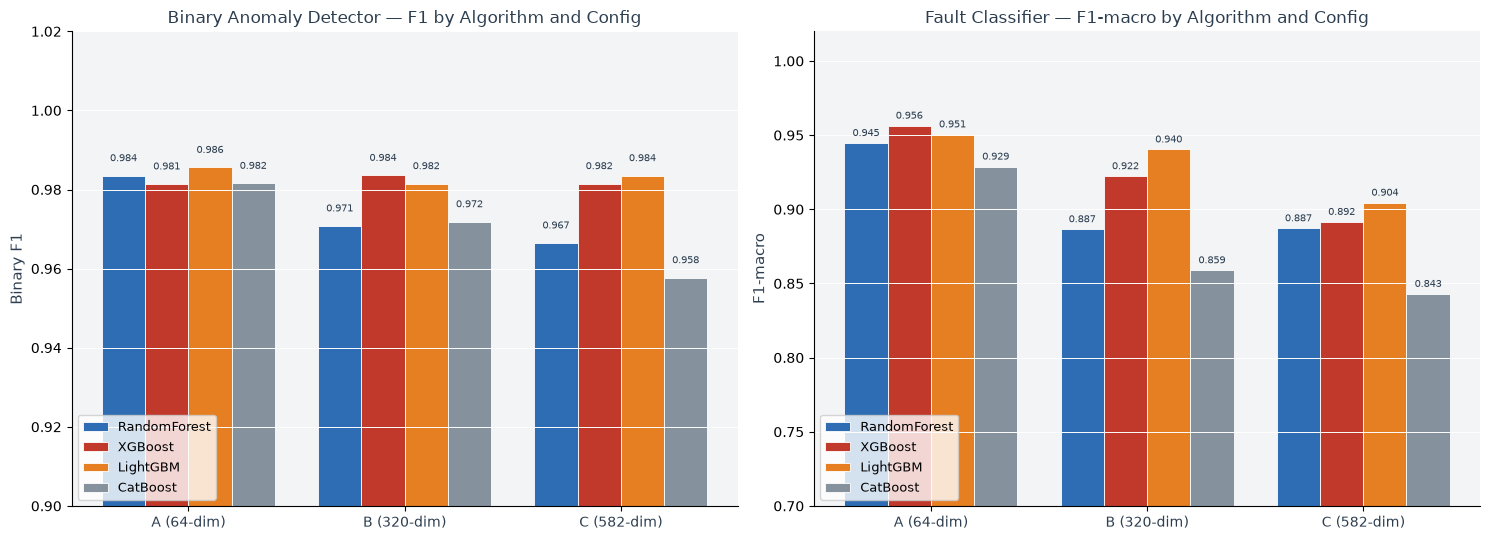

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

configs_order = ['A (64-dim)', 'B (320-dim)', 'C (582-dim)']
x = np.arange(len(configs_order))
width = 0.2

algo_colors = {
    'RandomForest': COLORS['normal'],
    'XGBoost':      COLORS['anomaly'],
    'LightGBM':     COLORS['jamming'],
    'CatBoost':     COLORS['synthetic'],
}

# Binary
for i, algo in enumerate(ALGORITHMS):
    f1s = [binary_results[algo][cfg]['f1'] for cfg in configs_order]
    offset = (i - 1.5) * width
    bars = axes[0].bar(x + offset, f1s, width, label=algo,
                       color=algo_colors[algo], edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, f1s):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=7.5,
                     color=COLORS['axis'])

axes[0].set_xticks(x)
axes[0].set_xticklabels(configs_order, fontsize=10, color=COLORS['axis'])
axes[0].set_ylabel('Binary F1', fontsize=11, color=COLORS['axis'])
axes[0].set_ylim(0.9, 1.02)
axes[0].set_title('Binary Anomaly Detector — F1 by Algorithm and Config',
                  fontsize=12, color=COLORS['axis'])
axes[0].set_facecolor(COLORS['grid'])
axes[0].grid(axis='y', color='white', linewidth=0.7)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(fontsize=9, loc='lower left')

# Fault classifier
for i, algo in enumerate(ALGORITHMS):
    f1s = [mc_results[algo][cfg]['f1_macro'] for cfg in configs_order]
    offset = (i - 1.5) * width
    bars = axes[1].bar(x + offset, f1s, width, label=algo,
                       color=algo_colors[algo], edgecolor='white', linewidth=0.6)
    for bar, val in zip(bars, f1s):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=7.5,
                     color=COLORS['axis'])

axes[1].set_xticks(x)
axes[1].set_xticklabels(configs_order, fontsize=10, color=COLORS['axis'])
axes[1].set_ylabel('F1-macro', fontsize=11, color=COLORS['axis'])
axes[1].set_ylim(0.7, 1.02)
axes[1].set_title('Fault Classifier — F1-macro by Algorithm and Config',
                  fontsize=12, color=COLORS['axis'])
axes[1].set_facecolor(COLORS['grid'])
axes[1].grid(axis='y', color='white', linewidth=0.7)
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'algorithm_comparison.png'), dpi=150)
plt.show()

## 10. Speed vs Accuracy Trade-off

In [10]:
print(f'{"Algorithm":<15} {"Config":>12} {"F1":>8} {"Time (s)":>10}')
print('-' * 50)

for cfg in configs_order:
    for algo in ALGORITHMS:
        r = binary_results[algo][cfg]
        print(f'{algo:<15} {cfg:>12} {r["f1"]:>8.4f} {r["time_sec"]:>10.1f}')
    print()

Algorithm             Config       F1   Time (s)
--------------------------------------------------
RandomForest      A (64-dim)   0.9835        3.7
XGBoost           A (64-dim)   0.9814        2.1
LightGBM          A (64-dim)   0.9856        0.8
CatBoost          A (64-dim)   0.9816        2.1

RandomForest     B (320-dim)   0.9708       10.5
XGBoost          B (320-dim)   0.9836        6.6
LightGBM         B (320-dim)   0.9815        4.7
CatBoost         B (320-dim)   0.9719        5.4

RandomForest     C (582-dim)   0.9665       15.7
XGBoost          C (582-dim)   0.9815       12.0
LightGBM         C (582-dim)   0.9835        7.5
CatBoost         C (582-dim)   0.9577        8.7



## 11. Final Recommendation

In [11]:
# Find the overall best combination
overall_best_binary = None
overall_best_mc     = None
best_binary_f1 = 0
best_mc_f1     = 0

for algo in ALGORITHMS:
    for cfg in configs_order:
        b = binary_results[algo][cfg]['f1']
        m = mc_results[algo][cfg]['f1_macro']
        if b > best_binary_f1:
            best_binary_f1 = b
            overall_best_binary = (algo, cfg)
        if m > best_mc_f1:
            best_mc_f1 = m
            overall_best_mc = (algo, cfg)

print('Overall Best Combinations:')
print(f'  Binary Detection:  {overall_best_binary[0]} + {overall_best_binary[1]} (F1 = {best_binary_f1:.4f})')
print(f'  Fault Classifier:  {overall_best_mc[0]} + {overall_best_mc[1]} (F1-macro = {best_mc_f1:.4f})')
print()
print('Comparison against Notebook 03 baseline (RandomForest + Config A):')
print(f'  Binary v03:        RandomForest + A: F1 = 0.9814')
print(f'  Binary v03c best:  {overall_best_binary[0]} + {overall_best_binary[1]}: F1 = {best_binary_f1:.4f}')
print(f'  Improvement: {(best_binary_f1 - 0.9814)*100:+.2f} percentage points')
print()
print(f'  Fault v03:         RandomForest + A: F1-macro = 0.9449')
print(f'  Fault v03c best:   {overall_best_mc[0]} + {overall_best_mc[1]}: F1-macro = {best_mc_f1:.4f}')
print(f'  Improvement: {(best_mc_f1 - 0.9449)*100:+.2f} percentage points')

Overall Best Combinations:
  Binary Detection:  LightGBM + A (64-dim) (F1 = 0.9856)
  Fault Classifier:  XGBoost + A (64-dim) (F1-macro = 0.9564)

Comparison against Notebook 03 baseline (RandomForest + Config A):
  Binary v03:        RandomForest + A: F1 = 0.9814
  Binary v03c best:  LightGBM + A (64-dim): F1 = 0.9856
  Improvement: +0.42 percentage points

  Fault v03:         RandomForest + A: F1-macro = 0.9449
  Fault v03c best:   XGBoost + A (64-dim): F1-macro = 0.9564
  Improvement: +1.15 percentage points


## 12. Save Complete Results

In [12]:
summary = {
    'binary':     {a: {c: {k: float(v) if k != 'time_sec' else float(v)
                            for k, v in binary_results[a][c].items()}
                       for c in configs_order} for a in ALGORITHMS},
    'multiclass': {a: {c: {k: float(v) if k != 'time_sec' else float(v)
                            for k, v in mc_results[a][c].items()}
                       for c in configs_order} for a in ALGORITHMS},
    'best_binary':     {'algo': overall_best_binary[0], 'config': overall_best_binary[1], 'f1': float(best_binary_f1)},
    'best_multiclass': {'algo': overall_best_mc[0],     'config': overall_best_mc[1],     'f1_macro': float(best_mc_f1)},
}

with open(os.path.join(DATA_DIR, 'algorithm_comparison_results.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved: algorithm_comparison_results.json')

Saved: algorithm_comparison_results.json
